Training networks with different hidden-layer activation functions...

  [sigmoid] epoch    0 loss = 1.1870
  [sigmoid] epoch  200 loss = 0.1328
  [sigmoid] epoch  400 loss = 0.0766
  [sigmoid] epoch  600 loss = 0.0616
  [sigmoid] epoch  800 loss = 0.0547
  [sigmoid] epoch 1000 loss = 0.0507
  [sigmoid] epoch 1200 loss = 0.0480
  [sigmoid] epoch 1400 loss = 0.0462
  -> sigmoid  final_loss=0.0454 train_acc=98.33% test_acc=100.00%

  [tanh] epoch    0 loss = 1.3479
  [tanh] epoch  200 loss = 0.0516
  [tanh] epoch  400 loss = 0.0426
  [tanh] epoch  600 loss = 0.0390
  [tanh] epoch  800 loss = 0.0361
  [tanh] epoch 1000 loss = 0.0335
  [tanh] epoch 1200 loss = 0.0307
  [tanh] epoch 1400 loss = 0.0275
  -> tanh     final_loss=0.0257 train_acc=98.33% test_acc=96.67%

  [relu] epoch    0 loss = 0.6037
  [relu] epoch  200 loss = 0.0456
  [relu] epoch  400 loss = 0.0387
  [relu] epoch  600 loss = 0.0370
  [relu] epoch  800 loss = 0.0362
  [relu] epoch 1000 loss = 0.0359
  [relu] epoch 1200 loss

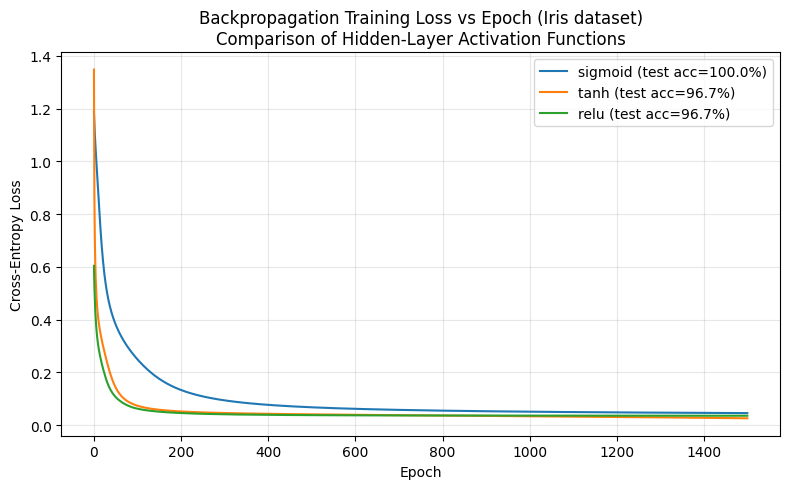

In [ ]:
"""
Artificial Neural Network with Backpropagation (implemented from scratch using NumPy)
=======================================================================================
Lab Exercise: Build an ANN by implementing the Backpropagation algorithm and test it
using an appropriate dataset. Vary the activation functions and compare results.

Dataset : Iris (3-class classification, 4 input features)
Network : 4 (input) -> 8 (hidden, configurable activation) -> 3 (output, softmax)
Loss    : Categorical Cross-Entropy
Training: Full-batch Gradient Descent, backpropagation derived and coded manually.
"""

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)


# ---------------------------------------------------------------------------
# 1. Activation functions and their derivatives
# ---------------------------------------------------------------------------

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(a):
    return a * (1 - a)


def tanh(x):
    return np.tanh(x)


def tanh_derivative(a):
    return 1 - a ** 2


def relu(x):
    return np.maximum(0, x)


def relu_derivative(a):
    return (a > 0).astype(float)


ACTIVATIONS = {
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh": (tanh, tanh_derivative),
    "relu": (relu, relu_derivative),
}


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)


# ---------------------------------------------------------------------------
# 2. Neural Network class (forward pass + manual backpropagation)
# ---------------------------------------------------------------------------

class NeuralNetwork:

    def __init__(self, n_input, n_hidden, n_output,
                 activation="sigmoid", lr=0.1):

        self.lr = lr
        self.act_name = activation
        self.act, self.act_deriv = ACTIVATIONS[activation]

        # Weight initialisation
        scale1 = (
            np.sqrt(2.0 / n_input)
            if activation == "relu"
            else np.sqrt(1.0 / n_input)
        )

        scale2 = (
            np.sqrt(2.0 / n_hidden)
            if activation == "relu"
            else np.sqrt(1.0 / n_hidden)
        )

        self.W1 = np.random.randn(n_input, n_hidden) * scale1
        self.b1 = np.zeros((1, n_hidden))

        self.W2 = np.random.randn(n_hidden, n_output) * scale2
        self.b2 = np.zeros((1, n_output))

    # ---------------- Forward pass ----------------

    def forward(self, X):

        self.Z1 = X @ self.W1 + self.b1

        self.A1 = self.act(self.Z1)

        self.Z2 = self.A1 @ self.W2 + self.b2

        self.A2 = softmax(self.Z2)

        return self.A2

    # ---------------- Loss ----------------

    def compute_loss(self, y_pred, y_true):

        eps = 1e-9

        return -np.mean(
            np.sum(
                y_true * np.log(y_pred + eps),
                axis=1
            )
        )

    # ---------------- Backward pass ----------------

    def backward(self, X, y_true):

        m = X.shape[0]

        # Output layer gradient
        dZ2 = (self.A2 - y_true) / m

        dW2 = self.A1.T @ dZ2

        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        )

        # Propagate error back to hidden layer
        dA1 = dZ2 @ self.W2.T

        dZ1 = dA1 * self.act_deriv(self.A1)

        dW1 = X.T @ dZ1

        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )

        # Gradient descent update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ---------------- Training loop ----------------

    def train(self, X, y, epochs=1000, verbose=False):

        losses = []

        for epoch in range(epochs):

            y_pred = self.forward(X)

            loss = self.compute_loss(
                y_pred,
                y
            )

            losses.append(loss)

            self.backward(
                X,
                y
            )

            if verbose and epoch % 200 == 0:

                print(
                    f"  [{self.act_name}] "
                    f"epoch {epoch:4d} "
                    f"loss = {loss:.4f}"
                )

        return losses

    # ---------------- Prediction ----------------

    def predict(self, X):

        return np.argmax(
            self.forward(X),
            axis=1
        )


# ---------------------------------------------------------------------------
# 3. Load and prepare the dataset (Iris)
# ---------------------------------------------------------------------------

data = load_iris()

X = data.data
y = data.target

n_classes = len(np.unique(y))


# One-hot encode targets
y_onehot = np.eye(n_classes)[y]


X_train, X_test, y_train, y_test, y_train_oh, y_test_oh = train_test_split(
    X,
    y,
    y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ---------------------------------------------------------------------------
# 4. Train one network per activation function and compare
# ---------------------------------------------------------------------------

results = {}

EPOCHS = 1500
HIDDEN_NEURONS = 8
LR = 0.5


print(
    "Training networks with different hidden-layer "
    "activation functions...\n"
)


for act_name in ["sigmoid", "tanh", "relu"]:

    nn = NeuralNetwork(
        n_input=4,
        n_hidden=HIDDEN_NEURONS,
        n_output=3,
        activation=act_name,
        lr=LR
    )

    losses = nn.train(
        X_train,
        y_train_oh,
        epochs=EPOCHS,
        verbose=True
    )

    train_pred = nn.predict(X_train)

    test_pred = nn.predict(X_test)

    train_acc = np.mean(
        train_pred == y_train
    )

    test_acc = np.mean(
        test_pred == y_test
    )

    results[act_name] = {
        "losses": losses,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "final_loss": losses[-1],
    }

    print(
        f"  -> {act_name:8s} "
        f"final_loss={losses[-1]:.4f} "
        f"train_acc={train_acc * 100:.2f}% "
        f"test_acc={test_acc * 100:.2f}%\n"
    )


# ---------------------------------------------------------------------------
# 5. Results comparison table
# ---------------------------------------------------------------------------

print("=" * 60)

print(
    f"{'Activation':<12}"
    f"{'Final Loss':<14}"
    f"{'Train Acc %':<14}"
    f"{'Test Acc %':<12}"
)

print("=" * 60)


for act_name, r in results.items():

    print(
        f"{act_name:<12}"
        f"{r['final_loss']:<14.4f}"
        f"{r['train_acc'] * 100:<14.2f}"
        f"{r['test_acc'] * 100:<12.2f}"
    )


print("=" * 60)


# ---------------------------------------------------------------------------
# 6. Plot: training loss curves for each activation function
# ---------------------------------------------------------------------------

plt.figure(figsize=(8, 5))


for act_name, r in results.items():

    plt.plot(
        r["losses"],
        label=f"{act_name} "
              f"(test acc={r['test_acc'] * 100:.1f}%)"
    )


plt.xlabel("Epoch")

plt.ylabel("Cross-Entropy Loss")

plt.title(
    "Backpropagation Training Loss vs Epoch (Iris dataset)\n"
    "Comparison of Hidden-Layer Activation Functions"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()


# Save plot in current folder
plt.savefig(
    "activation_comparison.png",
    dpi=150
)

print("\nPlot saved as activation_comparison.png")